# Swan Coastal Plain Weed Data EDA

This notebook retrieves public weed records directly from the source APIs and examines **data structure, annual record counts, and spatial distribution**.

1. **ALA dr794 / GBIF mirror** — selected weed records from *Weed and native flora data for the Swan Coastal Plain*
2. **Dandjoo** — nine representative introduced weeds in the Perth and Dandaragan Plateau IBRA subregions

Questions addressed:

- What are the dimensions, fields, and data types of each dataset?
- Which fields have substantial missingness?
- How uneven are annual record counts?
- How are occurrence points distributed spatially?
- Which fields can support initial-state and annual-spread estimation, and what is missing?

API results are cached in `data/raw/`; summary tables are written to `data/processed/`.

In [1]:
from pathlib import Path
import json
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "figures"
for directory in (RAW_DIR, PROCESSED_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ALA_CACHE = RAW_DIR / "ala_dr794.csv.gz"
DANDJOO_CACHE = RAW_DIR / "dandjoo_scp_weeds.csv.gz"

ALA_URL = "https://api.ala.org.au/occurrences/occurrences/search"
GBIF_URL = "https://api.gbif.org/v1/occurrence/search"
GBIF_DATASET_KEY = "63fa6322-9962-44a5-8691-24cdb26e1370"
DANDJOO_URL = "https://dandjoo.bio.wa.gov.au/api/records/search/"

REGIONS = {
    "Dandaragan Plateau": "6272233aa82892035bc8d9f8",
    "Perth": "62722338a82892035bc8d9c8",
}

WEED_SPECIES = [
    "Hypochaeris glabra",
    "Briza maxima",
    "Gladiolus caryophyllaceus",
    "Ehrharta calycina",
    "Ehrharta longiflora",
    "Pelargonium capitatum",
    "Arctotheca calendula",
    "Trachyandra divaricata",
    "Avena barbata",
]

print("Working directory:", ROOT)
print("Target weeds:", len(WEED_SPECIES))

Working directory: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model
Target weeds: 9


## 1. Data retrieval

The notebook retrieves the nine target weed species from the dataset's GBIF mirror. This avoids current ALA API availability problems while preserving the same published dataset identity.

Dandjoo is paged in batches of 500 for each species and IBRA subregion. GeoJSON point coordinates are flattened into longitude and latitude columns.

In [2]:
def get_json(session, method, url, *, params=None, payload=None, retries=4):
    for attempt in range(retries):
        try:
            response = session.request(
                method, url, params=params, json=payload, timeout=90
            )
            response.raise_for_status()
            return response.json()
        except requests.RequestException:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)


def fetch_ala_dr794(force=False):
    if ALA_CACHE.exists() and not force:
        return pd.read_csv(ALA_CACHE, low_memory=False)

    print("Retrieving dr794 from its GBIF mirror.")
    df = pd.DataFrame(fetch_gbif_dr794())
    df.to_csv(ALA_CACHE, index=False, compression="gzip")
    return df

    session = requests.Session()
    page_size = 1000
    offset = 0
    rows = []
    fields = ",".join([
        "uuid", "scientificName", "species", "genus", "family",
        "decimalLatitude", "decimalLongitude", "year", "eventDate",
        "locationID", "catalogNumber", "taxonConceptID",
        "basisOfRecord", "occurrenceStatus", "dataResourceUid",
    ])

    try:
        while True:
            payload = get_json(
                session,
                "GET",
                ALA_URL,
                params={
                    "q": "data_resource_uid:dr794",
                    "pageSize": page_size,
                    "startIndex": offset,
                    "fl": fields,
                },
            )
            occurrences = payload.get("occurrences", [])
            for record in occurrences:
                other = record.get("otherProperties") or {}
                rows.append({
                    "record_id": record.get("uuid"),
                    "scientific_name": record.get("scientificName"),
                    "species": record.get("species"),
                    "genus": record.get("genus"),
                    "family": record.get("family"),
                    "latitude": record.get("decimalLatitude"),
                    "longitude": record.get("decimalLongitude"),
                    "year": record.get("year"),
                    "event_date": record.get("eventDate"),
                    "location_id": record.get("locationID") or other.get("locationID"),
                    "catalog_number": record.get("catalogNumber") or record.get("raw_catalogNumber"),
                    "taxon_concept_id": record.get("taxonConceptID"),
                    "basis_of_record": record.get("basisOfRecord"),
                    "occurrence_status": record.get("occurrenceStatus"),
                    "data_resource_uid": record.get("dataResourceUid"),
                    "retrieval_source": "ALA",
                })

            offset += len(occurrences)
            if not occurrences or offset >= payload.get("totalRecords", 0):
                break
            if offset % 10000 == 0:
                print(f"ALA: {offset:,} records fetched")
    except requests.RequestException as exc:
        print(f"ALA API unavailable ({exc}). Falling back to the GBIF mirror.")
        rows = fetch_gbif_dr794()

    df = pd.DataFrame(rows)
    df.to_csv(ALA_CACHE, index=False, compression="gzip")
    return df


def fetch_gbif_dr794():
    page_size = 300
    tasks = []
    for target_species in WEED_SPECIES:
        first = get_json(
            requests.Session(),
            "GET",
            GBIF_URL,
            params={
                "dataset_key": GBIF_DATASET_KEY,
                "scientific_name": target_species,
                "limit": 0,
            },
        )
        tasks.extend((target_species, offset) for offset in range(0, first["count"], page_size))

    def fetch_page(target_species, page_offset):
        payload = get_json(
            requests.Session(),
            "GET",
            GBIF_URL,
            params={
                "dataset_key": GBIF_DATASET_KEY,
                "scientific_name": target_species,
                "limit": page_size,
                "offset": page_offset,
            },
        )
        page_rows = []
        for record in payload.get("results", []):
            page_rows.append({
                "record_id": record.get("occurrenceID") or record.get("key"),
                "scientific_name": record.get("scientificName"),
                "species": record.get("species"),
                "genus": record.get("genus"),
                "family": record.get("family"),
                "latitude": record.get("decimalLatitude"),
                "longitude": record.get("decimalLongitude"),
                "year": record.get("year"),
                "event_date": record.get("eventDate"),
                "location_id": record.get("locationID"),
                "catalog_number": record.get("catalogNumber"),
                "taxon_concept_id": record.get("taxonConceptID"),
                "basis_of_record": record.get("basisOfRecord"),
                "occurrence_status": record.get("occurrenceStatus"),
                "data_resource_uid": "dr794",
                "retrieval_source": "GBIF mirror",
                "query_species": target_species,
            })
        return target_species, page_offset, page_rows

    pages = {}
    with ThreadPoolExecutor(max_workers=8) as pool:
        futures = [pool.submit(fetch_page, species, offset) for species, offset in tasks]
        for completed, future in enumerate(as_completed(futures), start=1):
            species, page_offset, page_rows = future.result()
            pages[(species, page_offset)] = page_rows

    return [row for page_key in sorted(pages) for row in pages[page_key]]


def fetch_dandjoo_weeds(force=False):
    if DANDJOO_CACHE.exists() and not force:
        return pd.read_csv(DANDJOO_CACHE, low_memory=False)

    session = requests.Session()
    rows = []
    for query_species in WEED_SPECIES:
        for region_name, region_id in REGIONS.items():
            offset = 0
            while True:
                payload = {
                    "species": [query_species],
                    "region_id": region_id,
                    "offset": offset,
                    "limit": 500,
                    "sort": "date",
                    "descending": False,
                }
                result = get_json(session, "POST", DANDJOO_URL, payload=payload)
                records = result.get("results", [])
                for record in records:
                    geometry = record.get("location") or {}
                    coordinates = geometry.get("coordinates") or [None, None]
                    rows.append({
                        "record_id": record.get("id"),
                        "query_species": query_species,
                        "accepted_species": record.get("species"),
                        "recorded_species": record.get("recorded_species"),
                        "event_date": record.get("date"),
                        "longitude": coordinates[0] if len(coordinates) > 0 else None,
                        "latitude": coordinates[1] if len(coordinates) > 1 else None,
                        "data_type": record.get("datatype"),
                        "dataset": record.get("dataset"),
                        "submission_name": record.get("submission_name"),
                        "submission_set_name": record.get("submission_set_name"),
                        "data_provider": record.get("data_provider"),
                        "kingdom": record.get("kingdom"),
                        "conservation_status": record.get("conservation_status"),
                        "taxonomic_status": record.get("taxonomic_status"),
                        "region_query": region_name,
                    })
                offset += len(records)
                if not records or offset >= result.get("total", 0):
                    break
            print(f"Dandjoo: {query_species} / {region_name} complete")

    df = pd.DataFrame(rows).drop_duplicates("record_id")
    df.to_csv(DANDJOO_CACHE, index=False, compression="gzip")
    return df


ala = fetch_ala_dr794()
dandjoo = fetch_dandjoo_weeds()

dandjoo["event_date"] = pd.to_datetime(dandjoo["event_date"], errors="coerce")
dandjoo["year"] = dandjoo["event_date"].dt.year.astype("Int64")
ala["year"] = pd.to_numeric(ala["year"], errors="coerce").astype("Int64")

print(f"ALA dr794: {len(ala):,} rows")
print(f"Dandjoo weeds: {len(dandjoo):,} rows")

Retrieving dr794 from its GBIF mirror.


Dandjoo: Hypochaeris glabra / Dandaragan Plateau complete


Dandjoo: Hypochaeris glabra / Perth complete


Dandjoo: Briza maxima / Dandaragan Plateau complete


Dandjoo: Briza maxima / Perth complete
Dandjoo: Gladiolus caryophyllaceus / Dandaragan Plateau complete


...

Dandjoo: Ehrharta longiflora / Perth complete
Dandjoo: Pelargonium capitatum / Dandaragan Plateau complete


Dandjoo: Pelargonium capitatum / Perth complete
Dandjoo: Arctotheca calendula / Dandaragan Plateau complete


Dandjoo: Arctotheca calendula / Perth complete
Dandjoo: Trachyandra divaricata / Dandaragan Plateau complete


Dandjoo: Trachyandra divaricata / Perth complete
Dandjoo: Avena barbata / Dandaragan Plateau complete


Dandjoo: Avena barbata / Perth complete
ALA dr794: 1,516 rows
Dandjoo weeds: 3,682 rows


## 2. Data structure

In [3]:
def structure_table(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(dropna=True),
    }).sort_values(["missing_pct", "n_unique"], ascending=[False, False])


print("ALA dr794 shape:", ala.shape)
display(structure_table(ala))
display(ala.head(5))

ALA dr794 shape: (1516, 17)


,dtype,non_null,missing,missing_pct,n_unique
year,Int64,0,1516,100.0,0
event_date,object,0,1516,100.0,0
record_id,str,1516,0,0.0,1516
catalog_number,str,1516,0,0.0,1516
location_id,str,1516,0,0.0,744
latitude,float64,1516,0,0.0,740
longitude,float64,1516,0,0.0,736
scientific_name,str,1516,0,0.0,9
species,str,1516,0,0.0,9
taxon_concept_id,str,1516,0,0.0,9


,record_id,scientific_name,species,genus,family,latitude,longitude,year,event_date,location_id,catalog_number,taxon_concept_id,basis_of_record,occurrence_status,data_resource_uid,retrieval_source,query_species
0,a37b2edc-0168-4944-b136-4e8d98d2cb42,Arctotheca calendula (L.) K.Lewin,Arctotheca calendula,Arctotheca,Asteraceae,-31.842833,115.969932,<NA>,None,Cavs11,Cavs11|7838,https://id.biodiversity.org.au/taxon/apni/5126...,HUMAN_OBSERVATION,PRESENT,dr794,GBIF mirror,Arctotheca calendula
1,b3cee807-ef08-41ad-9691-527d3bd1440e,Arctotheca calendula (L.) K.Lewin,Arctotheca calendula,Arctotheca,Asteraceae,-33.599135,115.566500,<NA>,None,Plant02,Plant02|7838,https://id.biodiversity.org.au/taxon/apni/5126...,HUMAN_OBSERVATION,PRESENT,dr794,GBIF mirror,Arctotheca calendula
2,7fac1cf4-722a-4ea4-9218-2774c444d783,Arctotheca calendula (L.) K.Lewin,Arctotheca calendula,Arctotheca,Asteraceae,-31.761209,115.998006,<NA>,None,vines02,vines02|7838,https://id.biodiversity.org.au/taxon/apni/5126...,HUMAN_OBSERVATION,PRESENT,dr794,GBIF mirror,Arctotheca calendula
3,f8ec070a-7703-4ea3-88a6-26e0f01df9c8,Arctotheca calendula (L.) K.Lewin,Arctotheca calendula,Arctotheca,Asteraceae,-32.032751,115.824931,<NA>,None,wire02,wire02|7838,https://id.biodiversity.org.au/taxon/apni/5126...,HUMAN_OBSERVATION,PRESENT,dr794,GBIF mirror,Arctotheca calendula
4,0679126b-3108-4433-8db1-8e286ad73b3f,Arctotheca calendula (L.) K.Lewin,Arctotheca calendula,Arctotheca,Asteraceae,-32.929796,115.714361,<NA>,None,ELLIS-2,ELLIS-2|7838,https://id.biodiversity.org.au/taxon/apni/5126...,HUMAN_OBSERVATION,PRESENT,dr794,GBIF mirror,Arctotheca calendula


In [4]:
print("Dandjoo weed data shape:", dandjoo.shape)
display(structure_table(dandjoo))
display(dandjoo.head(5))

Dandjoo weed data shape: (3682, 17)


,dtype,non_null,missing,missing_pct,n_unique
conservation_status,object,0,3682,100.0,0
dataset,str,1109,2573,69.9,7
submission_name,str,2573,1109,30.1,32
submission_set_name,str,2573,1109,30.1,18
taxonomic_status,str,2728,954,25.9,1
record_id,str,3682,0,0.0,3682
longitude,float64,3682,0,0.0,1703
latitude,float64,3682,0,0.0,1574
event_date,datetime64[us],3682,0,0.0,526
year,Int64,3682,0,0.0,67


,record_id,query_species,accepted_species,recorded_species,event_date,longitude,latitude,data_type,dataset,submission_name,submission_set_name,data_provider,kingdom,conservation_status,taxonomic_status,region_query,year
0,2026CFBje7e709e0,Hypochaeris glabra,Hypochaeris glabra L.,Hypochaeris glabra L.,1990-10-26,115.77254,-30.97896,Systematic survey data,NaN,Southern Swan Coastal Plain,Native and weed flora of the southern Swan Coa...,"DBCA (Biodiversity, Conservation and Attractions)",Plantae,None,accepted,Dandaragan Plateau,1990
1,2026CFBjeb6051c4,Hypochaeris glabra,Hypochaeris glabra L.,Hypochaeris glabra L.,1990-11-21,116.00722,-31.17661,Systematic survey data,NaN,Southern Swan Coastal Plain,Native and weed flora of the southern Swan Coa...,"DBCA (Biodiversity, Conservation and Attractions)",Plantae,None,accepted,Dandaragan Plateau,1990
2,2026CFBjeb679f20,Hypochaeris glabra,Hypochaeris glabra L.,Hypochaeris glabra L.,1990-11-21,116.02199,-31.18882,Systematic survey data,NaN,Southern Swan Coastal Plain,Native and weed flora of the southern Swan Coa...,"DBCA (Biodiversity, Conservation and Attractions)",Plantae,None,accepted,Dandaragan Plateau,1990
3,2024DbDxi19a7411,Hypochaeris glabra,Hypochaeris glabra L.,Hypochaeris glabra L.,1991-10-20,116.02168,-31.63174,Species occurrence data,Swan Coastal Plain Survey,NaN,NaN,"DBCA (Biodiversity, Conservation and Attractions)",Plantae,None,NaN,Dandaragan Plateau,1991
4,2024DbDxi27a973b,Hypochaeris glabra,Hypochaeris glabra L.,Hypochaeris glabra L.,1991-10-20,116.02106,-31.63077,Species occurrence data,Swan Coastal Plain Survey,NaN,NaN,"DBCA (Biodiversity, Conservation and Attractions)",Plantae,None,NaN,Dandaragan Plateau,1991


In [5]:
summary = pd.DataFrame({
    "dataset": ["ALA dr794", "Dandjoo selected weeds"],
    "records": [len(ala), len(dandjoo)],
    "species": [ala["species"].nunique(), dandjoo["query_species"].nunique()],
    "unique_locations_or_points": [
        ala["location_id"].nunique(),
        dandjoo[["latitude", "longitude"]].drop_duplicates().shape[0],
    ],
    "records_with_coordinates": [
        ala[["latitude", "longitude"]].notna().all(axis=1).sum(),
        dandjoo[["latitude", "longitude"]].notna().all(axis=1).sum(),
    ],
    "records_with_year": [ala["year"].notna().sum(), dandjoo["year"].notna().sum()],
})
display(summary)
summary.to_csv(PROCESSED_DIR / "dataset_structure_summary.csv", index=False)

,dataset,records,species,unique_locations_or_points,records_with_coordinates,records_with_year
0,ALA dr794,1516,9,744,1516,0
1,Dandjoo selected weeds,3682,9,1797,3682,3682


### Structural observations

- ALA `dr794` is species-by-quadrat presence data with useful spatial structure, but record-level years are absent from the public occurrence records.
- Dandjoo provides observation dates, but the number of records in a year depends strongly on the survey projects active in that year.
- The public Dandjoo search response exposes core display fields rather than all 54 standard export fields. Detailed effort and protocol analysis requires the source files or a formal extract.

## 3. Selected weeds within ALA dr794

,records,sites
species,,
Hypochaeris glabra,534,534
Briza maxima,420,420
Gladiolus caryophyllaceus,182,182
Ehrharta calycina,108,108
Pelargonium capitatum,92,92
Ehrharta longiflora,86,86
Arctotheca calendula,35,35
Trachyandra divaricata,34,34
Avena barbata,25,25


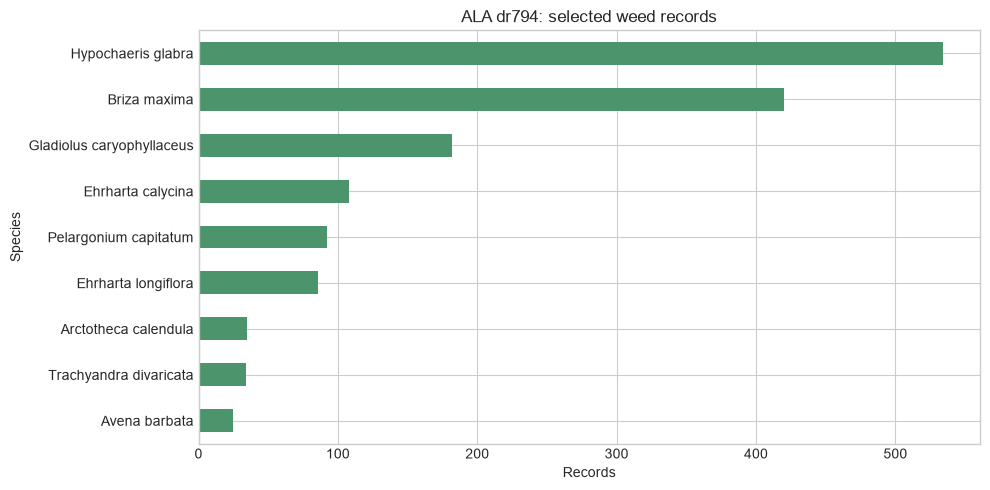

In [6]:
ala_weeds = ala[ala["species"].isin(WEED_SPECIES)].copy()
ala_weed_counts = (
    ala_weeds.groupby("species", dropna=False)
    .agg(records=("record_id", "size"), sites=("location_id", "nunique"))
    .sort_values("records", ascending=False)
)
display(ala_weed_counts)
ala_weed_counts.to_csv(PROCESSED_DIR / "ala_dr794_selected_weed_counts.csv")

fig, ax = plt.subplots(figsize=(10, 5))
ala_weed_counts.sort_values("records")["records"].plot.barh(ax=ax, color="#4C956C")
ax.set(title="ALA dr794: selected weed records", xlabel="Records", ylabel="Species")
fig.tight_layout()
fig.savefig(FIG_DIR / "ala_selected_weed_counts.png", dpi=160)
plt.show()

## 4. Dandjoo records by species and year

In [7]:
species_summary = (
    dandjoo.groupby("query_species")
    .agg(
        records=("record_id", "size"),
        unique_points=("record_id", lambda x: dandjoo.loc[x.index, ["latitude", "longitude"]].drop_duplicates().shape[0]),
        first_year=("year", "min"),
        last_year=("year", "max"),
        observed_years=("year", "nunique"),
        systematic_records=("data_type", lambda x: x.eq("Systematic survey data").sum()),
    )
    .sort_values("records", ascending=False)
)
display(species_summary)
species_summary.to_csv(PROCESSED_DIR / "dandjoo_weed_species_summary.csv")

,records,unique_points,first_year,last_year,observed_years,systematic_records
query_species,,,,,,
Hypochaeris glabra,1171,1059,1894,2025,36,839
Briza maxima,956,875,1885,2025,34,668
Gladiolus caryophyllaceus,466,438,1968,2025,27,328
Ehrharta calycina,301,287,1909,2025,25,232
Ehrharta longiflora,250,235,1901,2025,28,180
Pelargonium capitatum,200,189,1897,2025,30,110
Arctotheca calendula,153,151,1838,2025,32,101
Trachyandra divaricata,97,89,1976,2025,22,45
Avena barbata,88,85,1934,2025,25,70


,records,species_observed,unique_points
year,,,
1990,121,7,66
1991,241,8,129
1992,994,9,372
1993,485,9,256
1994,271,9,113
1995,262,9,109
1996,6,4,3
1997,2,2,2
1998,4,4,4


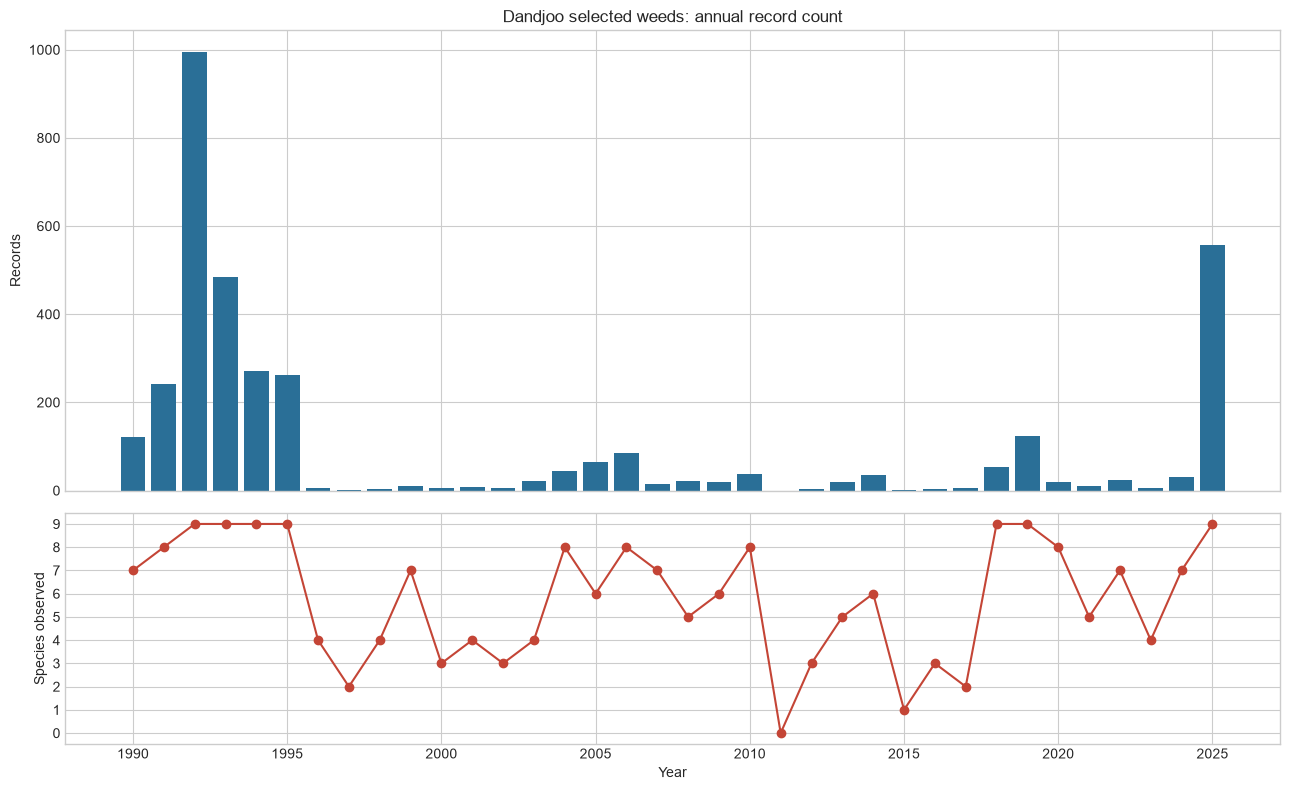

In [8]:
annual = (
    dandjoo.dropna(subset=["year"])
    .query("year >= 1990 and year <= 2025")
    .groupby("year")
    .agg(
        records=("record_id", "size"),
        species_observed=("query_species", "nunique"),
        unique_points=("record_id", lambda x: dandjoo.loc[x.index, ["latitude", "longitude"]].drop_duplicates().shape[0]),
    )
    .reindex(range(1990, 2026), fill_value=0)
)
annual.index.name = "year"
display(annual)
annual.to_csv(PROCESSED_DIR / "dandjoo_weed_annual_counts.csv")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].bar(annual.index, annual["records"], color="#2A6F97")
axes[0].set(ylabel="Records", title="Dandjoo selected weeds: annual record count")
axes[1].plot(annual.index, annual["species_observed"], marker="o", lw=1.5, color="#C44536")
axes[1].set(xlabel="Year", ylabel="Species observed", yticks=range(0, len(WEED_SPECIES) + 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "dandjoo_annual_counts.png", dpi=160)
plt.show()

### Species-by-year heatmap

Colour represents the annual record count for each species. Because counts are highly uneven, the colour scale uses `log(1 + count)`.

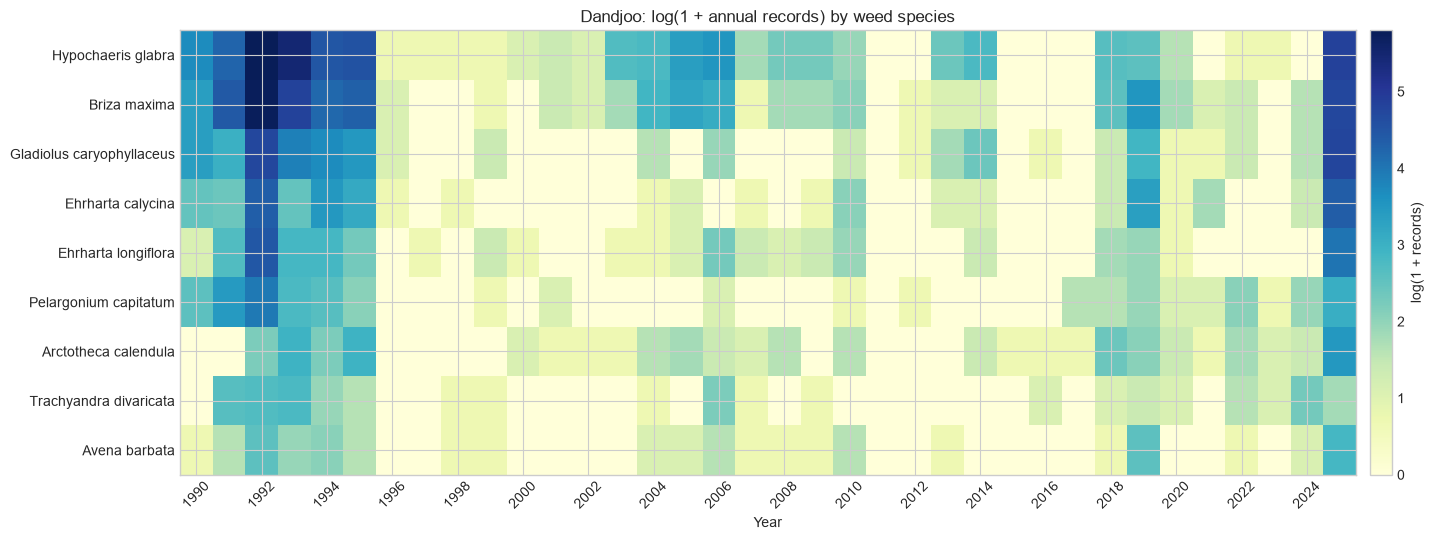

In [9]:
species_year = (
    dandjoo.dropna(subset=["year"])
    .query("year >= 1990 and year <= 2025")
    .pivot_table(index="query_species", columns="year", values="record_id", aggfunc="size", fill_value=0)
    .reindex(WEED_SPECIES)
    .reindex(columns=range(1990, 2026), fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 5.5))
image = ax.imshow(np.log1p(species_year.values), aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(len(species_year.index)), labels=species_year.index)
ax.set_xticks(range(0, len(species_year.columns), 2), labels=species_year.columns[::2], rotation=45)
ax.set(title="Dandjoo: log(1 + annual records) by weed species", xlabel="Year")
cbar = fig.colorbar(image, ax=ax, pad=0.01)
cbar.set_label("log(1 + records)")
fig.tight_layout()
fig.savefig(FIG_DIR / "dandjoo_species_year_heatmap.png", dpi=160)
plt.show()

## 5. Spatial distribution

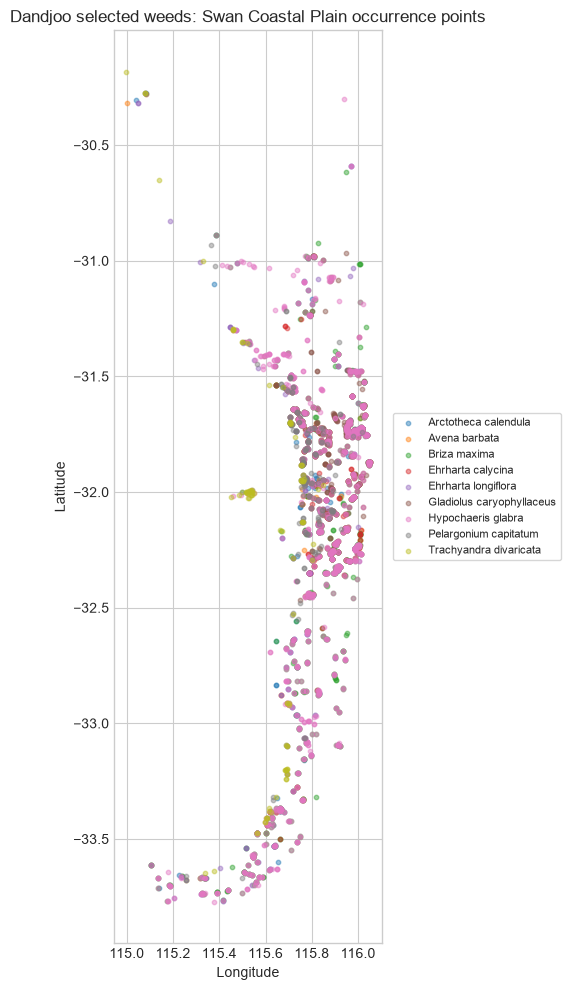

In [10]:
plot_df = dandjoo.dropna(subset=["longitude", "latitude"]).copy()

fig, ax = plt.subplots(figsize=(9, 10))
for species, group in plot_df.groupby("query_species"):
    ax.scatter(group["longitude"], group["latitude"], s=10, alpha=0.45, label=species)
ax.set(
    title="Dandjoo selected weeds: Swan Coastal Plain occurrence points",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(FIG_DIR / "dandjoo_all_points_by_species.png", dpi=160, bbox_inches="tight")
plt.show()

### Distribution by time period

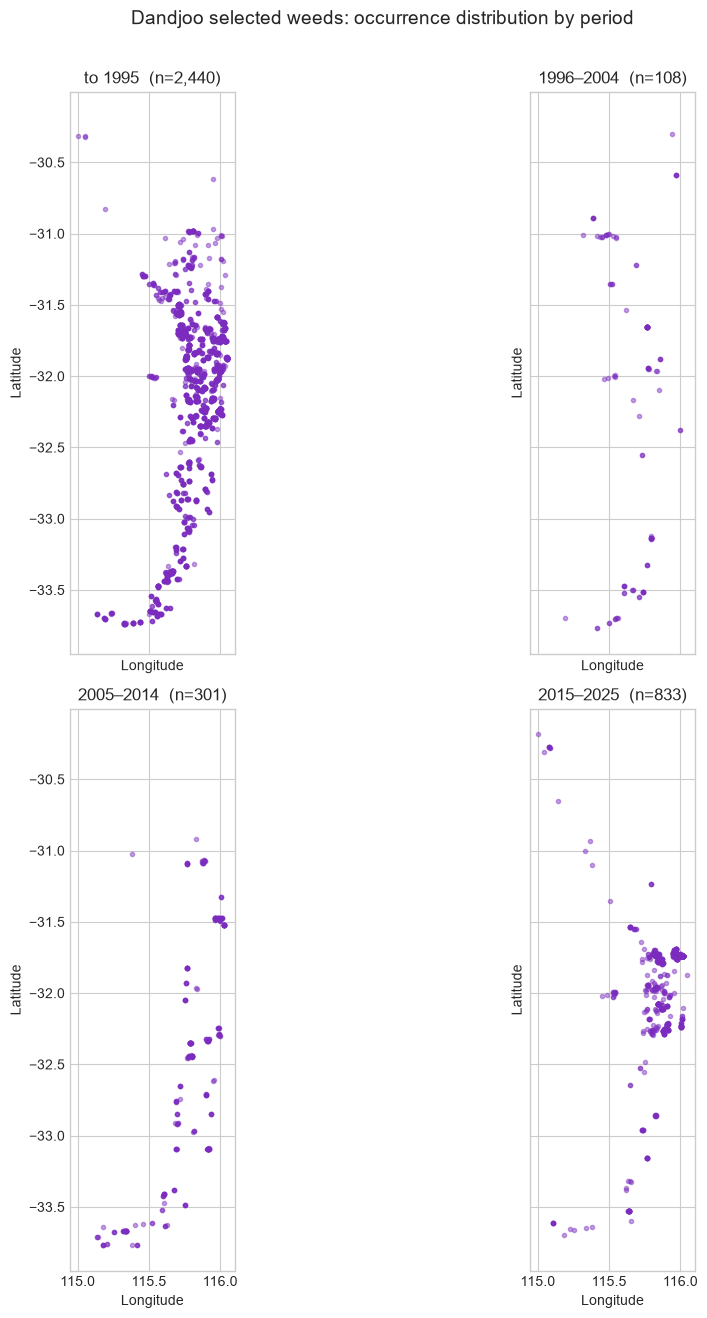

In [11]:
def period_label(year):
    if pd.isna(year):
        return None
    if year <= 1995:
        return "to 1995"
    if year <= 2004:
        return "1996–2004"
    if year <= 2014:
        return "2005–2014"
    if year <= 2025:
        return "2015–2025"
    return "after 2025"


plot_df["period"] = plot_df["year"].map(period_label)
periods = ["to 1995", "1996–2004", "2005–2014", "2015–2025"]
fig, axes = plt.subplots(2, 2, figsize=(12, 13), sharex=True, sharey=True)

for ax, period in zip(axes.flat, periods):
    part = plot_df[plot_df["period"] == period]
    ax.scatter(part["longitude"], part["latitude"], s=9, alpha=0.45, color="#7B2CBF")
    ax.set_title(f"{period}  (n={len(part):,})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Dandjoo selected weeds: occurrence distribution by period", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "dandjoo_points_by_period.png", dpi=160, bbox_inches="tight")
plt.show()

### Function for plotting any selected year

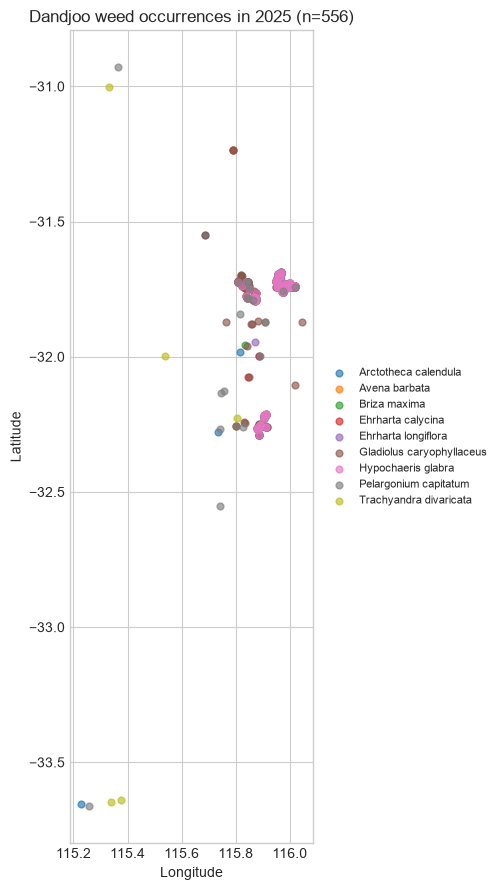

In [12]:
def plot_year(year, species=None):
    data = plot_df[plot_df["year"] == year]
    if species is not None:
        data = data[data["query_species"].isin(species)]

    fig, ax = plt.subplots(figsize=(8, 9))
    for name, group in data.groupby("query_species"):
        ax.scatter(group["longitude"], group["latitude"], s=24, alpha=0.65, label=name)
    ax.set(
        title=f"Dandjoo weed occurrences in {year} (n={len(data):,})",
        xlabel="Longitude",
        ylabel="Latitude",
    )
    if len(data):
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()


plot_year(2025)

## 6. ALA dr794 spatial baseline

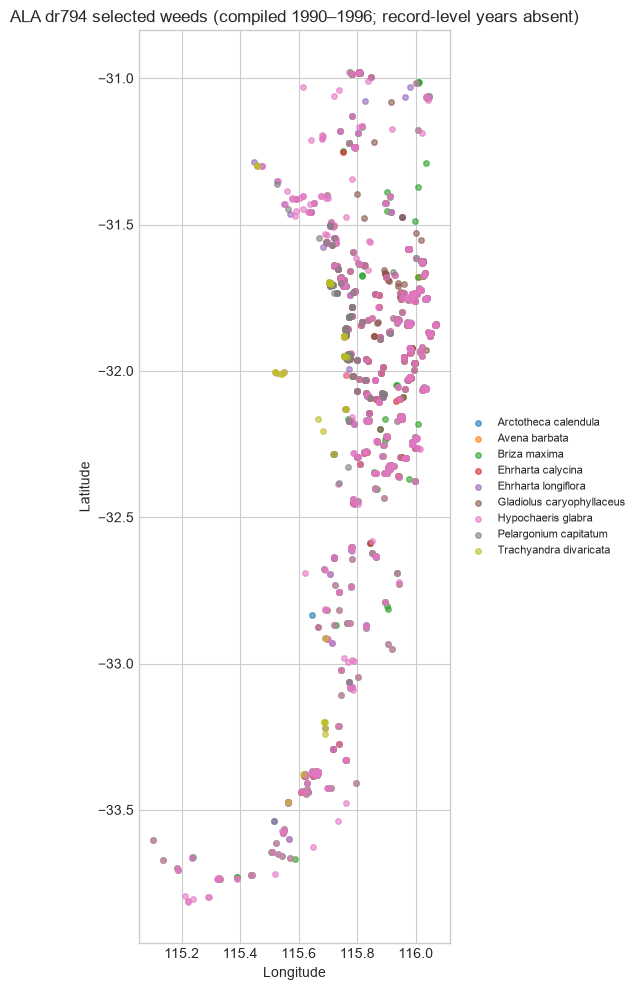

In [13]:
ala_map = ala_weeds.dropna(subset=["longitude", "latitude"])
fig, ax = plt.subplots(figsize=(9, 10))
for species, group in ala_map.groupby("species"):
    ax.scatter(group["longitude"], group["latitude"], s=16, alpha=0.6, label=species)
ax.set(
    title="ALA dr794 selected weeds (compiled 1990–1996; record-level years absent)",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(FIG_DIR / "ala_dr794_selected_weeds_map.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Multi-year site revisits and data sources

In [14]:
dandjoo["coord_key"] = (
    dandjoo["longitude"].round(5).astype("string")
    + ","
    + dandjoo["latitude"].round(5).astype("string")
)

revisit = (
    dandjoo.groupby(["query_species", "coord_key"])
    .agg(records=("record_id", "size"), years=("year", "nunique"), first_year=("year", "min"), last_year=("year", "max"))
    .reset_index()
)

display(
    revisit.groupby("query_species")
    .agg(
        coordinate_sites=("coord_key", "nunique"),
        sites_seen_multiple_years=("years", lambda x: x.gt(1).sum()),
        max_years_at_one_site=("years", "max"),
    )
    .sort_values("coordinate_sites", ascending=False)
)

display(
    dandjoo["dataset"].fillna("<not exposed in public response>")
    .value_counts()
    .rename_axis("dataset")
    .to_frame("records")
    .head(20)
)

,coordinate_sites,sites_seen_multiple_years,max_years_at_one_site
query_species,,,
Hypochaeris glabra,1059,13,2
Briza maxima,875,6,3
Gladiolus caryophyllaceus,438,0,1
Ehrharta calycina,287,0,1
Ehrharta longiflora,235,3,2
Pelargonium capitatum,189,0,1
Arctotheca calendula,151,1,2
Trachyandra divaricata,89,0,1
Avena barbata,85,0,1


,records
dataset,
<not exposed in public response>,2573
Swan Coastal Plain Survey,830
iNaturalist data,168
Australasian Virtual Herbarium Records,78
Island Weeds,14
Salinity Action Plan Flora Survey Data,9
BGPA Specimens,8
Scarp Survey,2


## 8. Preliminary conclusions from the EDA

1. **ALA dr794 can inform the initial spatial state.**  
   It contains many quadrats and species, but no record-level years. The 1990–1996 compilation period therefore needs to be treated as a single baseline window.

2. **Dandjoo has dates, but annual sampling is highly uneven.**  
   Changes in annual record counts cannot be interpreted directly as population changes. An observation-effort model using year, data source, and total plant records is needed.

3. **Use changes in latent occupancy, not raw annual differences.**  
   Annual grid-cell occupancy should be imputed with a state-space model, and spread should be estimated from differences in posterior occupancy probabilities.

4. **Pool multiple species with a hierarchical model.**  
   Species can share road, climate, and fire effects while retaining species-specific persistence, local-dispersal, and long-distance-dispersal parameters.

### Recommended next steps

- Retrieve the same nine species from all ALA Western Australian records and deduplicate them against Dandjoo.
- Construct grid-cell-by-year observation effort from all plant records or systematic survey events.
- Compare results using 500 m, 1 km, and 2 km grids.
- Join BoM climate, DEA Fractional Cover, fire history, and road-distance predictors by grid cell and year.
- Use the 1990–1996 ALA quadrat dataset to inform the initial occupancy probability.